<a href="https://colab.research.google.com/github/gunavathibaskaran170/DeepLearning/blob/main/Mnist_Image_Detection_using_Deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
mnist=keras.datasets.mnist
(x_train,y_train),(x_test,y_test)=mnist.load_data()
x_train,x_test=x_train/255.0, x_test/255.0 # it converting into the grayscale range 0 too 1

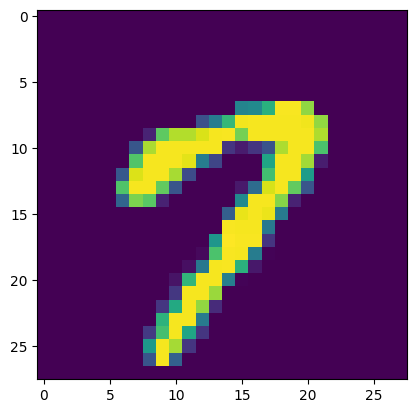

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[15]) # range 0 to 59999

In [ ]:
x_train.shape

(60000, 28, 28)

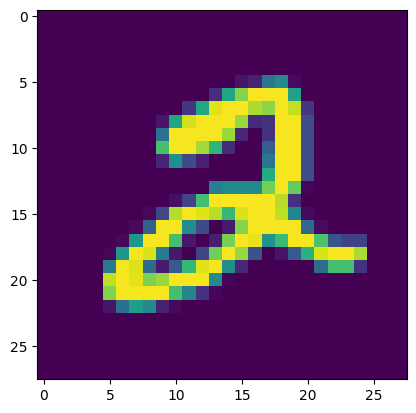

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[5])

In [ ]:
y_train[112]

np.uint8(1)

In [ ]:
model=keras.Sequential([
    layers.Flatten(input_shape=(28,28,1)), #[Grayscale Channel] ─── (Values 0 to 255) ───> Final Black & White Image
    #input_shape = ( 28 , 28 , 1 )
    #            │    │    │
    #        Height Width  Color Channels
    layers.Dense(128,activation='relu'), # 128 epoch take time to process if the accuracy is lower we can the
    layers.Dense(10,activation='softmax')]
)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

In [ ]:
history=model.fit(x_train,y_train,epochs=7,validation_split=0.1)

Epoch 1/7
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9209 - loss: 0.2755 - val_accuracy: 0.9643 - val_loss: 0.1294
Epoch 2/7
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9633 - loss: 0.1238 - val_accuracy: 0.9688 - val_loss: 0.1062
Epoch 3/7
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9744 - loss: 0.0844 - val_accuracy: 0.9718 - val_loss: 0.0993
Epoch 4/7
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9808 - loss: 0.0638 - val_accuracy: 0.9758 - val_loss: 0.0882
Epoch 5/7
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9850 - loss: 0.0489 - val_accuracy: 0.9785 - val_loss: 0.0765
Epoch 6/7
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9880 - loss: 0.0373 - val_accuracy: 0.9798 - val_loss: 0.0775
Epoch 7/7
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9909 - loss: 0.0295 - val_accuracy: 0.9777 - val_loss: 0.0841


In [ ]:
y_pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
y_pred[1703]

array([5.6811950e-07, 1.0223919e-04, 2.2105537e-03, 9.0295961e-03,
       1.2859849e-09, 5.4731634e-05, 3.5018619e-09, 9.8799121e-01,
       7.4823329e-05, 5.3618109e-04], dtype=float32)

In [ ]:
import numpy as np
y_pred_out=np.argmax(y_pred,axis=1) # it convert the array into number like most winning percentage
y_pred_out[1703]

np.int64(7)

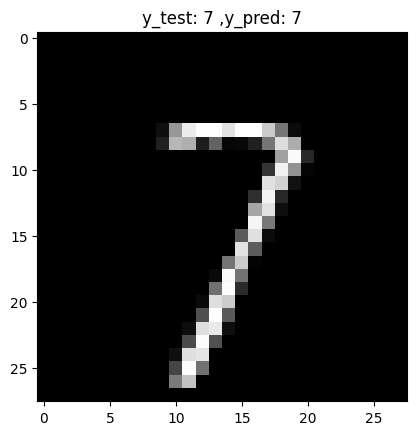

In [ ]:
plt.imshow(x_test[1703], cmap='gray') # this shows the actual image
true_label = y_test[1703] # x have assignment a value
predicted_label = np.argmax(y_pred[1703]) # whether it is predicting or not
plt.title(f"y_test: {true_label} ,y_pred: {predicted_label}")
plt.show()

In [ ]:
model.save("dl.h5")

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

In [ ]:
img =cv2.imread("/content/drive/MyDrive/DATASET /2.jpeg",0)

In [ ]:
cv2_imshow(img)

In [ ]:
img=cv2.resize(img,(28,28))
cv2_imshow(img)

In [ ]:
img=255-img
img= img/255.0
img=img.reshape(1,28,28)
p=model.predict(img)
p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[2.0073058e-18, 1.9660090e-21, 2.3606424e-06, 2.6676109e-10,
        0.0000000e+00, 9.9763238e-01, 2.3031526e-03, 3.8230760e-15,
        6.2116720e-05, 1.0537007e-17]], dtype=float32)

In [ ]:
p_val=np.argmax(p)
p_val

np.int64(5)

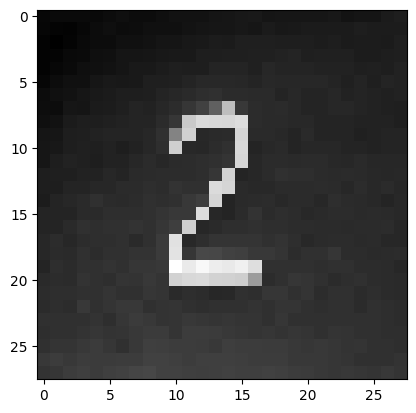

In [ ]:
plt.imshow(img.reshape(28,28),cmap='gray')

In [ ]:
from google.colab.patches import cv2_imshow

In [ ]:
img1=cv2.imread("/content/drive/MyDrive/DATASET /2i.jpeg",0)
img1=cv2.resize(img1,(28,28))
img1=255-img1
img1=img1/255.0

In [ ]:
img1.shape

(28, 28)

In [ ]:
print(model.input_shape)

(None, 28, 28, 1)


In [ ]:
img1=img1.reshape(1,28,28)
pre=model.predict(img1)
pred_val=np.argmax(pre)
pred_val


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


np.int64(8)

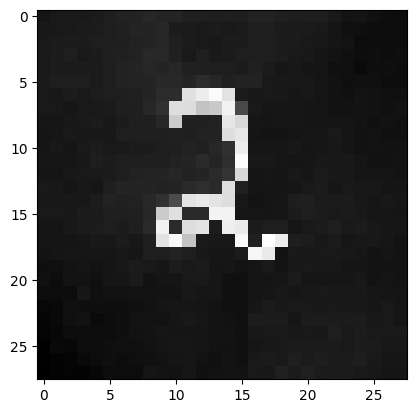

In [ ]:
plt.imshow(img1.reshape(28,28),cmap='gray')